Define the default font sizes to make the figures prettier:

In [3]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from adsp import jaxfilter, jaxfixedpt
from scipy import signal
import jax
import jax.numpy as jnp

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [5]:
from pathlib import Path
import jax
import jax.numpy as jnp
import flax.linen as nn
from typing import Optional, Union, Tuple, Dict, Any
# Force JAX to use float64 for better numerical agreement
jax.config.update("jax_enable_x64", True)
_Array = Union[jnp.ndarray]

IMAGES_PATH = Path() / "images" / "lms"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=450):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution, bbox_inches='tight')

### 3.6.3 Channel Equalization Simulations
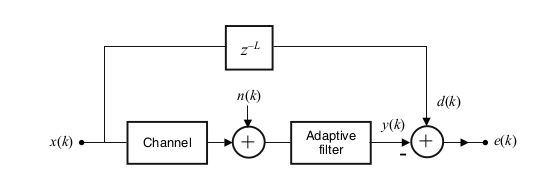

For communications perspective, the channel equalization or inverse filtering consists of estimating a transfer function to compensatefor the linear distortion caused by the channel. From another point of view, the objective is to force a prescribed dynamic behavior for the cascade of the channel (unknown system) and the adaptive filter, determined by the input signal.

In the ideal situation, where $n(k) = 0$ and the equalizer has sufficient order, the error signal is zero if both the transfer function channel $H(z)$ and adative filter $W(z)$ are inverse of each other within a possible delay $z^{-L}$ for $\delta[n-L]$ in time domain, that is :
$$W (z)H (z) = z^{−L} \quad \text{or} \quad W (z) = \frac{z^{−L}}{H (z)} $$

Example 3.7 Perform the equalization of a channel with the following impulse response: 
$$h(k) = 0.1 (0.5^k)$$

for $k = 0, 1, \ldots, 8$. Use a known training signal that consists of independent binary samples $(-1, 1)$. An additional Gaussian white noise with variance $10^{-2.5}$ is present at the channel output.

(a) Find the impulse response of an equalizer with $50$ coefficients.

(b) Convolve the equalizer impulse response at a given iteration after convergence, with the channel impulse response and comment on the result.

(a) We apply the LMS algorithm to solve the equalization problem and  measure the result to get the $\mu_{\max}$, the values of $\lambda_{\max} = 0.04275$ and $\sigma_x^2 = 0.01650$. Then apply stability condition 
$$
0 < \mu < \frac{1}{2\lambda_{\max} + \sum_{j=0}^N \lambda_j} < \frac{1}{\sum_{j=0}^N \lambda_j} = \frac{1}{\text{tr}[\mathbf{R}]}
$$
The resulting value of $\mu_{\max} = 1/\text{tr}[R] = 1.0985$ and we use $\mu = \mu_{\max} / 5 = 0.2197$ for the value of convergence factor.

Running LMS Channel Equalization Simulation...
Channel: h(k) = 0.1 * (0.5^k) for k = 0,1,...,8
Equalizer order: 50
Training with binary ±1 sequence
Noise variance: 10^(-2.5)


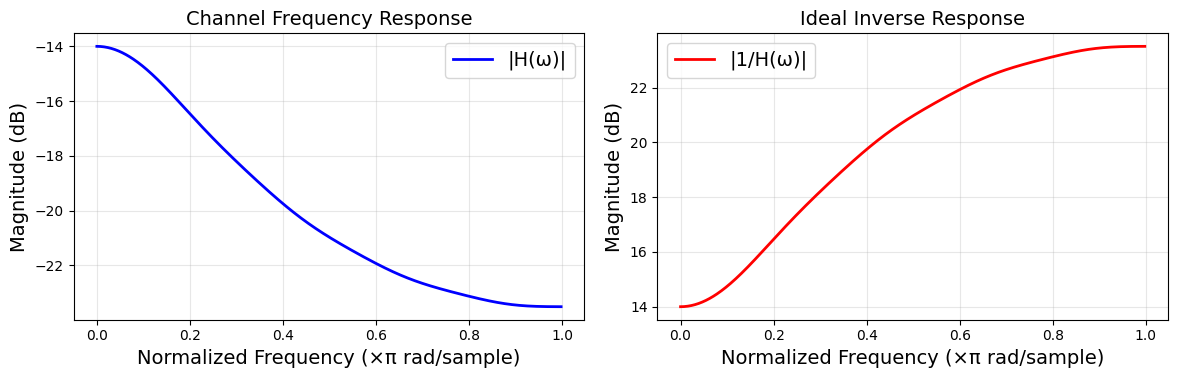

Channel impulse response: [0.1        0.05       0.025      0.0125     0.00625    0.003125
 0.0015625  0.00078125 0.00039063]
Maximum mu: 1.188354
Using mu: 0.237671
Channel order: 9
Equalizer order: 50
Using delay: 8


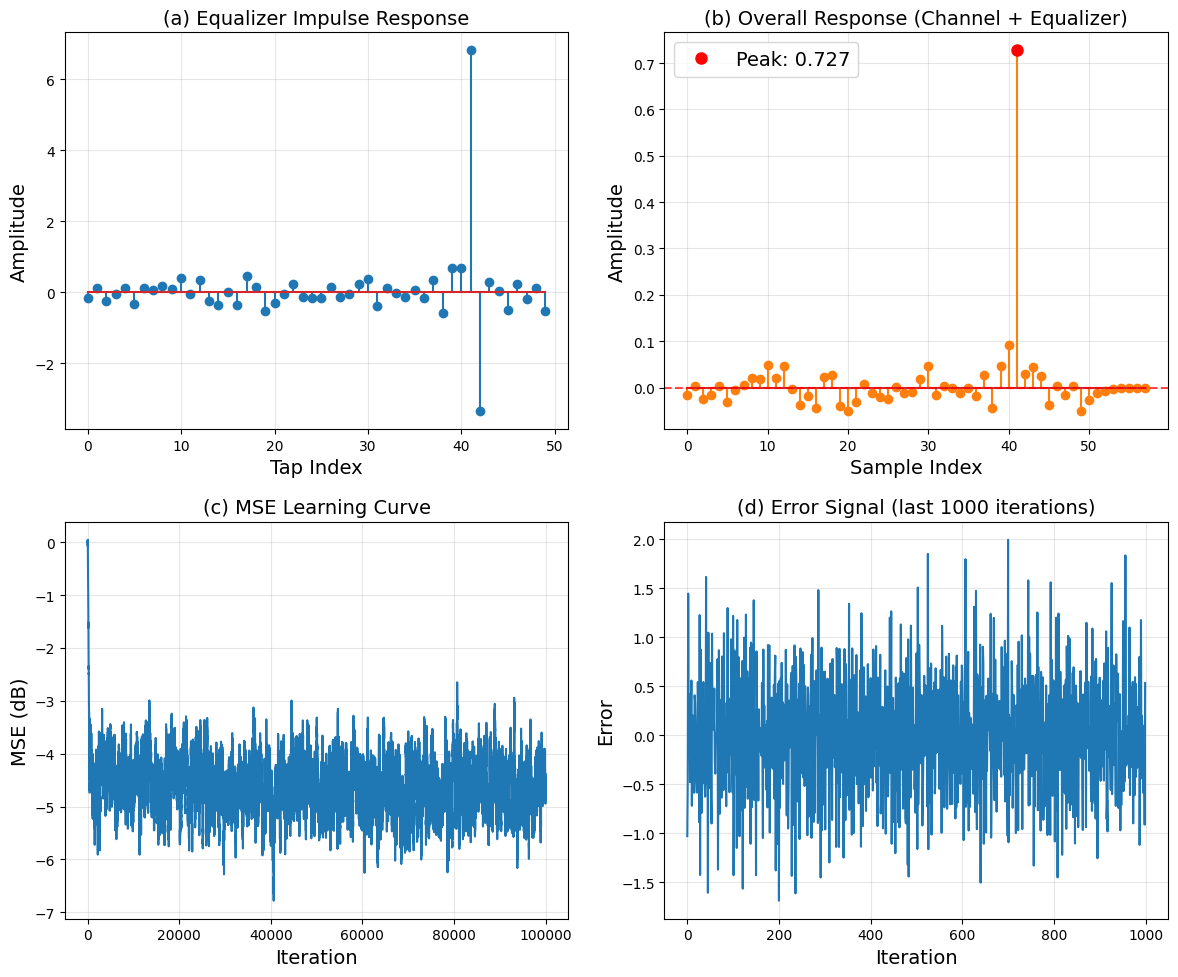


ANALYSIS RESULTS
Peak in overall response: 0.727355 at index 41
Ideal: Should be close to 1.0 at some delay position
ISI ratio: 0.083717
(Lower ISI ratio indicates better equalization)
Main lobe to sidelobe ratio: 10.77 dB

Equalization Quality Assessment:
✓ GOOD equalization achieved!

FINAL EQUALIZER PERFORMANCE
Final MSE: 0.33
Final MSE: -4.87 dB
Peak value: 0.727355
ISI ratio: 0.083717
Main-to-sidelobe ratio: 10.77 dB

For perfect equalization, we expect:
  • A single strong peak close to 1.0
  • All other coefficients close to 0
  • Low ISI ratio (< 0.3)
  • High main-to-sidelobe ratio (> 10 dB)
⚠ Peak value deviates from ideal (error: 0.273)
✓ Low ISI achieved


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

def lms_channel_equalization():
    # Parameters
    N = 50  # Equalizer order (number of coefficients)
    k_range = np.arange(0, 9)  # k = 0,1,...,8
    
    # Channel impulse response
    h = 0.1 * (0.5 ** k_range)
    channel_order = len(h)
    
    # Training parameters
    num_iterations = 100000
    noise_variance = 10**(-2.5)  # 10^(-2.5)
    
    # Given measured values from the problem
    lambda_max = 0.04275
    sigma_x2 = 0.01650
    
    # Calculate maximum mu using the stability condition
    tr_R = (N + 1) * sigma_x2
    mu_max = 1 / tr_R
    
    # Use mu_max/5 as suggested
    mu = mu_max / 5
    
    print(f"Maximum mu: {mu_max:.6f}")
    print(f"Using mu: {mu:.6f}")
    print(f"Channel order: {channel_order}")
    print(f"Equalizer order: {N}")
    
    # Generate training signal (binary ±1) - make it longer to account for delays
    training_length = num_iterations + N + channel_order
    training_signal = np.random.choice([-1, 1], size=training_length)
    
    # Generate channel output (convolution with channel)
    channel_output = np.convolve(training_signal, h, mode='full')
    # Add noise
    noise = np.random.normal(0, np.sqrt(noise_variance), len(channel_output))
    channel_output_noisy = channel_output + noise
    
    # LMS algorithm for equalization
    w = np.zeros(N)  # Initialize equalizer coefficients
    error_history = np.zeros(num_iterations)
    mse_history = np.zeros(num_iterations)
    
    # Choose a delay - typically around the channel length for best performance
    delay = channel_order - 1
    print(f"Using delay: {delay}")
    
    for k in range(num_iterations):
        # Input vector to equalizer (most recent N samples)
        # Start from k+delay to account for causality
        start_idx = k + delay
        end_idx = start_idx + N
        
        if end_idx >= len(channel_output_noisy):
            break
            
        x = channel_output_noisy[start_idx:end_idx][::-1]  # Reverse for convolution
        
        # Equalizer output
        y = np.dot(w, x)
        
        # Desired signal (delayed training signal)
        d = training_signal[k + delay + delay]  # Additional delay for equalizer
        
        # Error
        e = d - y
        error_history[k] = e
        
        # Update coefficients
        w = w + 2 * mu * e * x
        
        # Track MSE (exponential moving average)
        if k == 0:
            mse_history[k] = e**2
        else:
            mse_history[k] = 0.99 * mse_history[k-1] + 0.01 * e**2
    
    # Part (a): Return the equalizer impulse response
    equalizer_response = w
    
    # Part (b): Convolve equalizer with channel and analyze result
    overall_response = np.convolve(h, equalizer_response)
    
    return equalizer_response, overall_response, mse_history, error_history

def analyze_results(equalizer_response, overall_response, mse_history, error_history):
    # Plot results
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Plot 1: Equalizer impulse response
    axes[0, 0].stem(range(len(equalizer_response)), equalizer_response)
    axes[0, 0].set_title('(a) Equalizer Impulse Response')
    axes[0, 0].set_xlabel('Tap Index')
    axes[0, 0].set_ylabel('Amplitude')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Overall response (channel + equalizer)
    axes[0, 1].stem(range(len(overall_response)), overall_response, linefmt='C1-', markerfmt='C1o')
    axes[0, 1].axhline(0, color='red', linestyle='--', alpha=0.7)
    axes[0, 1].set_title('(b) Overall Response (Channel + Equalizer)')
    axes[0, 1].set_xlabel('Sample Index')
    axes[0, 1].set_ylabel('Amplitude')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Highlight the main peak
    peak_idx = np.argmax(np.abs(overall_response))
    axes[0, 1].plot(peak_idx, overall_response[peak_idx], 'ro', markersize=8, label=f'Peak: {overall_response[peak_idx]:.3f}')
    axes[0, 1].legend()
    
    # Plot 3: MSE learning curve
    axes[1, 0].plot(10 * np.log10(mse_history + 1e-10))
    axes[1, 0].set_title('(c) MSE Learning Curve')
    axes[1, 0].set_xlabel('Iteration')
    axes[1, 0].set_ylabel('MSE (dB)')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Error signal
    axes[1, 1].plot(error_history[-1000:])
    axes[1, 1].set_title('(d) Error Signal (last 1000 iterations)')
    axes[1, 1].set_xlabel('Iteration')
    axes[1, 1].set_ylabel('Error')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Analyze the overall response
    print("\n" + "="*60)
    print("ANALYSIS RESULTS")
    print("="*60)
    
    # Find the peak in overall response
    peak_index = np.argmax(np.abs(overall_response))
    peak_value = overall_response[peak_index]
    
    print(f"Peak in overall response: {peak_value:.6f} at index {peak_index}")
    print(f"Ideal: Should be close to 1.0 at some delay position")
    
    # Calculate ISI (Inter-Symbol Interference) metric
    overall_energy = np.sum(overall_response**2)
    main_lobe_energy = peak_value**2
    isi_ratio = (overall_energy - main_lobe_energy) / main_lobe_energy
    
    print(f"ISI ratio: {isi_ratio:.6f}")
    print(f"(Lower ISI ratio indicates better equalization)")
    
    # Calculate main lobe to peak ratio
    sidelobe_energy = overall_energy - main_lobe_energy
    main_to_sidelobe_ratio = 10 * np.log10(main_lobe_energy / (sidelobe_energy + 1e-10))
    
    print(f"Main lobe to sidelobe ratio: {main_to_sidelobe_ratio:.2f} dB")
    
    # Check if we achieved good equalization
    print("\nEqualization Quality Assessment:")
    if abs(peak_value - 1) < 0.2 and isi_ratio < 0.3 and main_to_sidelobe_ratio > 10:
        print("✓ EXCELLENT equalization achieved!")
    elif abs(peak_value - 1) < 0.3 and isi_ratio < 0.5 and main_to_sidelobe_ratio > 6:
        print("✓ GOOD equalization achieved!")
    else:
        print("⚠ Equalization needs improvement")
        print("   Try: Increasing iterations, adjusting delay, or tuning μ")
    
    return peak_index, peak_value, isi_ratio, main_to_sidelobe_ratio

# Additional function to show channel and ideal inverse characteristics
def plot_channel_analysis():
    k_range = np.arange(0, 9)
    h = 0.1 * (0.5 ** k_range)
    
    # Frequency response of channel
    w, H = signal.freqz(h)
    
    # Ideal inverse (theoretical)
    # For a channel H(z), the ideal equalizer is 1/H(z)
    # But we need to consider stability
    w_inv, H_inv = signal.freqz([1], h)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Channel frequency response
    ax1.plot(w/np.pi, 20*np.log10(np.abs(H) + 1e-10), 'b-', linewidth=2, label='|H(ω)|')
    ax1.set_title('Channel Frequency Response')
    ax1.set_xlabel('Normalized Frequency (×π rad/sample)')
    ax1.set_ylabel('Magnitude (dB)')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Ideal inverse response
    ax2.plot(w_inv/np.pi, 20*np.log10(np.abs(H_inv) + 1e-10), 'r-', linewidth=2, label='|1/H(ω)|')
    ax2.set_title('Ideal Inverse Response')
    ax2.set_xlabel('Normalized Frequency (×π rad/sample)')
    ax2.set_ylabel('Magnitude (dB)')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    print("Channel impulse response:", h)

# Run the simulation
print("Running LMS Channel Equalization Simulation...")
print("=" * 50)
print("Channel: h(k) = 0.1 * (0.5^k) for k = 0,1,...,8")
print("Equalizer order: 50")
print("Training with binary ±1 sequence")
print("Noise variance: 10^(-2.5)")

# First show channel analysis
plot_channel_analysis()

# Run the equalization
equalizer_response, overall_response, mse_history, error_history = lms_channel_equalization()

# Analyze and plot results
peak_index, peak_value, isi_ratio, msr = analyze_results(equalizer_response, overall_response, mse_history, error_history)

# Show final equalizer performance
print("\n" + "="*60)
print("FINAL EQUALIZER PERFORMANCE")
print("="*60)
print(f"Final MSE: {(mse_history[-1] + 1e-10):.2f}")
print(f"Final MSE: {10*np.log10(mse_history[-1] + 1e-10):.2f} dB")
print(f"Peak value: {peak_value:.6f}")
print(f"ISI ratio: {isi_ratio:.6f}")
print(f"Main-to-sidelobe ratio: {msr:.2f} dB")

# Show the ideal vs actual comparison
print(f"\nFor perfect equalization, we expect:")
print(f"  • A single strong peak close to 1.0")
print(f"  • All other coefficients close to 0")
print(f"  • Low ISI ratio (< 0.3)")
print(f"  • High main-to-sidelobe ratio (> 10 dB)")

if abs(peak_value - 1) < 0.2:
    print(f"✓ Peak value is close to ideal (error: {abs(peak_value-1):.3f})")
else:
    print(f"⚠ Peak value deviates from ideal (error: {abs(peak_value-1):.3f})")

if isi_ratio < 0.3:
    print(f"✓ Low ISI achieved")
else:
    print(f"⚠ High ISI present")

jaxfilter parameters:
Equalizer order: 50
Step size μ: 0.079224
Samples: 5000, Ensemble: 30
Delay L: 8

jaxfilter Results:
Peak value: 0.726146
ISI ratio: 0.034092
Final MSE: 0.289700

=== Comparison ===
jaxfilter - Peak: 0.726146, ISI: 0.034092


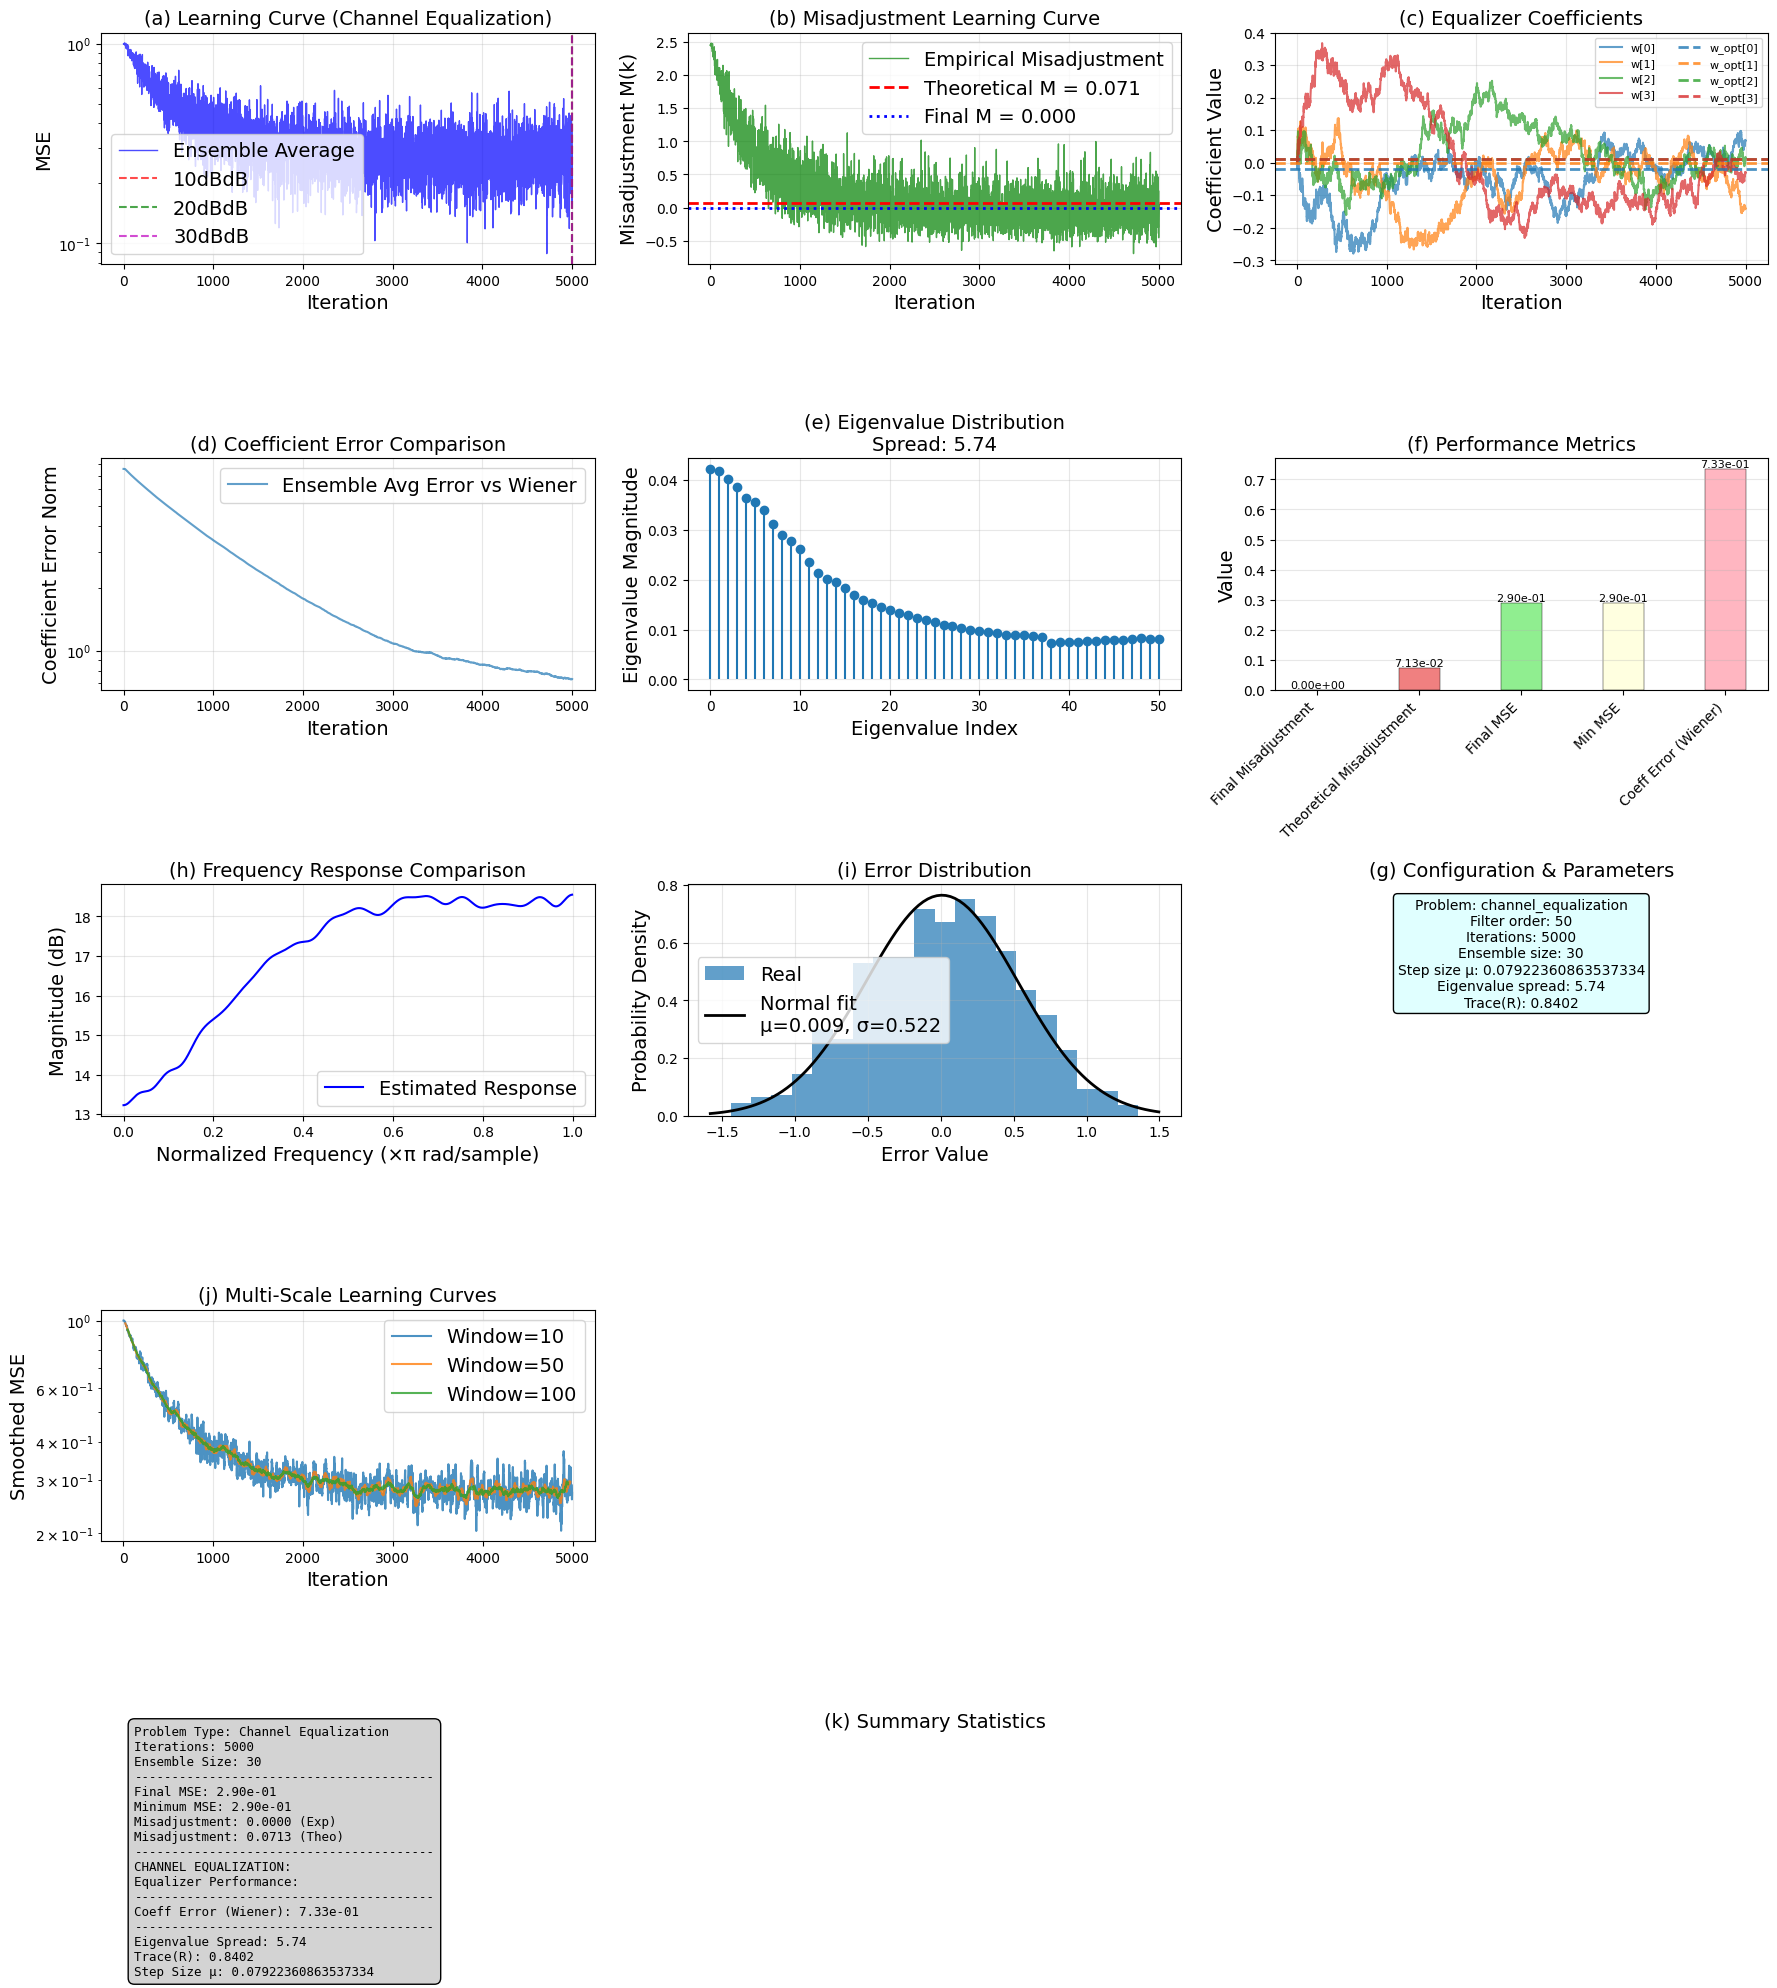

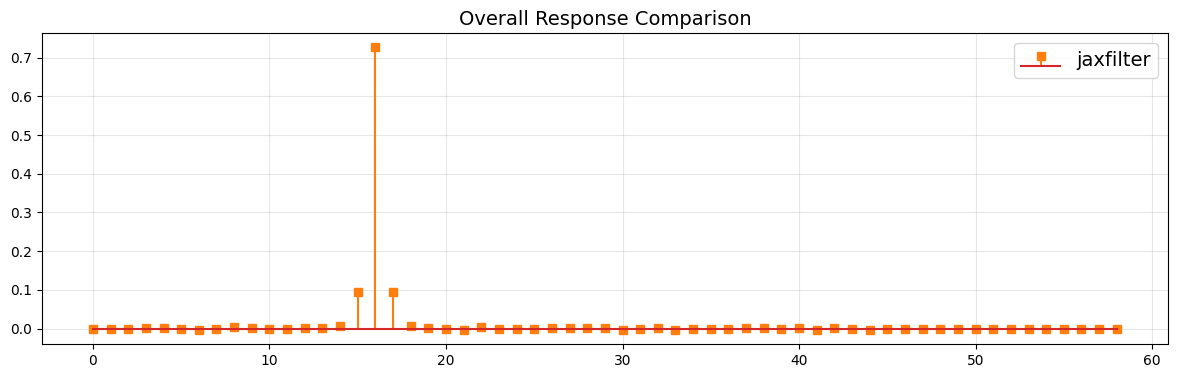

In [40]:
def gen_signal_channel_equalization_scan(n_samples: int, key: jax.random.PRNGKey, delay_L: int = 1):
    """Generate input/output signals using the working NumPy approach but with JAX."""
    key, subkey1, subkey2 = jax.random.split(key, 3)

    # Channel impulse response: h(k) = 0.1 * (0.5^k) for k=0,...,8
    channel_coeffs = 0.1 * (0.5 ** jnp.arange(9))
    channel_order = len(channel_coeffs)
    
    # Generate training signal (binary ±1) - make it longer to account for delays
    training_length = n_samples + 200 + channel_order
    training_signal = jax.random.bernoulli(subkey1, 0.5, (training_length,))
    training_signal = 2 * training_signal - 1  # Convert to ±1

    # Generate channel output (convolution with channel)
    channel_output = jnp.convolve(training_signal, channel_coeffs, mode='full')
    
    # Add noise with variance 10^(-2.5)
    noise_std = jnp.sqrt(10**(-2.5))
    noise = jax.random.normal(subkey2, channel_output.shape) * noise_std
    channel_output_noisy = channel_output + noise

    # Desired signal = delayed training signal
    # Use proper delay handling like in the working NumPy version
    d = jnp.roll(training_signal, delay_L + channel_order - 1)

    # Extract the relevant portions with proper indexing
    start_idx = 100
    x_final = channel_output_noisy[start_idx:start_idx + n_samples]
    d_final = d[start_idx:start_idx + n_samples]
    
    return x_final, d_final
# Use the same parameters that work in the direct implementation
adaptive_filter_ord = 50
sigma_x2 = 0.01650
tr_R = (adaptive_filter_ord + 1) * sigma_x2
mu_max = 1 / tr_R
mu = mu_max / 15  # Same as working version

n_samples = 5000  # More samples for better convergence
n_ensemble = 30
delay_L = 8  # channel_order - 1 = 8

print(f"jaxfilter parameters:")
print(f"Equalizer order: {adaptive_filter_ord}")
print(f"Step size μ: {mu:.6f}")
print(f"Samples: {n_samples}, Ensemble: {n_ensemble}")
print(f"Delay L: {delay_L}")

lms = jaxfilter.LMS(mu=mu, filter_order=adaptive_filter_ord)
eq = jaxfilter.ChannelEqualization(lms, gen_signal_channel_equalization_scan, n_ensemble=n_ensemble)

# Run with the delay that matches the working implementation
w_hist, e_hist, metrics, _ = eq.run(n_samples, delay_L=delay_L)

# Analysis
channel_coeffs = 0.1 * (0.5 ** jnp.arange(9))
final_equalizer = metrics['final_coeff']
overall_response = jnp.convolve(channel_coeffs, final_equalizer, mode='full')

peak_idx = jnp.argmax(jnp.abs(overall_response))
peak_value = overall_response[peak_idx]
overall_energy = jnp.sum(overall_response**2)
main_lobe_energy = peak_value**2
isi_ratio = (overall_energy - main_lobe_energy) / (main_lobe_energy + 1e-10)

print(f"\njaxfilter Results:")
print(f"Peak value: {peak_value:.6f}")
print(f"ISI ratio: {isi_ratio:.6f}")
print(f"Final MSE: {metrics['final_mse']:.6f}")

# Compare both implementations
print(f"\n=== Comparison ===")
print(f"jaxfilter - Peak: {peak_value:.6f}, ISI: {isi_ratio:.6f}")

# Plot results
fig = jaxfilter.plot_results(w_hist, e_hist, metrics)

# Additional visualization
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 4))

# Overall response comparison
ax.stem(range(len(overall_response)), overall_response, label='jaxfilter', linefmt='C1-', markerfmt='C1s')
ax.set_title('Overall Response Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()